## 1.Необхідні бібліотеки

In [51]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime, timedelta

## 2. Завантаження даних

In [52]:
confirmed = pd.read_csv('CONVENIENT_global_confirmed_cases.csv')
deaths = pd.read_csv('CONVENIENT_global_deaths.csv')

print("Структура confirmed файлу:")
print(confirmed.head(3))
print("\nСтовпці confirmed:")
print(confirmed.columns.tolist()[:10])

Структура confirmed файлу:
   Country/Region  Afghanistan  Albania  Algeria  Andorra  Angola  Antarctica  \
0  Province/State          NaN      NaN      NaN      NaN     NaN         NaN   
1         1/23/20          0.0      0.0      0.0      0.0     0.0         0.0   
2         1/24/20          0.0      0.0      0.0      0.0     0.0         0.0   

   Antigua and Barbuda  Argentina  Armenia  ... Uruguay Uzbekistan Vanuatu  \
0                  NaN        NaN      NaN  ...     NaN        NaN     NaN   
1                  0.0        0.0      0.0  ...     0.0        0.0     0.0   
2                  0.0        0.0      0.0  ...     0.0        0.0     0.0   

  Venezuela Vietnam West Bank and Gaza Winter Olympics 2022 Yemen  Zambia  \
0       NaN     NaN                NaN                  NaN   NaN     NaN   
1       0.0     2.0                0.0                  0.0   0.0     0.0   
2       0.0     0.0                0.0                  0.0   0.0     0.0   

   Zimbabwe  
0       NaN 

## 3. Підготовка даних для Andorra та Estonia

In [64]:
import pandas as pd

confirmed = pd.read_csv('CONVENIENT_global_confirmed_cases.csv')
deaths = pd.read_csv('CONVENIENT_global_deaths.csv')

print("Структура confirmed файлу:")
print(confirmed.head(3))
print("Стовпці confirmed:")
print(confirmed.columns.tolist()[:10])

def prepare_country_data(confirmed_df, deaths_df, country_name):
    print(f"Підготовка даних для {country_name}")
    
    if country_name not in confirmed_df.columns:
        print(f"Країна {country_name} не знайдена серед стовпців")
        similar_countries = [col for col in confirmed_df.columns if country_name.lower() in col.lower()]
        if similar_countries:
            print(f"Схожі назви: {similar_countries}")
        return None
    
    dates = confirmed_df['Country/Region'].iloc[1:].reset_index(drop=True)
    
    confirmed_values = confirmed_df[country_name].iloc[1:].reset_index(drop=True)
    deaths_values = deaths_df[country_name].iloc[1:].reset_index(drop=True)
    
    df = pd.DataFrame({
        'Date': pd.to_datetime(dates, format='%m/%d/%y'),
        'Confirmed': pd.to_numeric(confirmed_values, errors='coerce'),
        'Deaths': pd.to_numeric(deaths_values, errors='coerce')
    })
    
    df = df.dropna()
    
    print(f"Створено DataFrame з {len(df)} записами")
    print(f"Діапазон дат: {df['Date'].min()} до {df['Date'].max()}")
    print(f"Останні 5 записів:\n{df.tail()}")
    
    return df

print("Завантаження даних")

andorra_data = prepare_country_data(confirmed, deaths, 'Andorra')
estonia_data = prepare_country_data(confirmed, deaths, 'Estonia')

if andorra_data is not None:
    print(f"Дані для Andorra успішно завантажено! Розмір: {andorra_data.shape}")
else:
    print("Не вдалося завантажити дані для Andorra")

if estonia_data is not None:
    print(f"Дані для Estonia успішно завантажено! Розмір: {estonia_data.shape}")
else:
    print("Не вдалося завантажити дані для Estonia")

Структура confirmed файлу:
   Country/Region  Afghanistan  Albania  Algeria  Andorra  Angola  Antarctica  \
0  Province/State          NaN      NaN      NaN      NaN     NaN         NaN   
1         1/23/20          0.0      0.0      0.0      0.0     0.0         0.0   
2         1/24/20          0.0      0.0      0.0      0.0     0.0         0.0   

   Antigua and Barbuda  Argentina  Armenia  ... Uruguay Uzbekistan Vanuatu  \
0                  NaN        NaN      NaN  ...     NaN        NaN     NaN   
1                  0.0        0.0      0.0  ...     0.0        0.0     0.0   
2                  0.0        0.0      0.0  ...     0.0        0.0     0.0   

  Venezuela Vietnam West Bank and Gaza Winter Olympics 2022 Yemen  Zambia  \
0       NaN     NaN                NaN                  NaN   NaN     NaN   
1       0.0     2.0                0.0                  0.0   0.0     0.0   
2       0.0     0.0                0.0                  0.0   0.0     0.0   

   Zimbabwe  
0       NaN 

## 4. Проста модель SIR


АНАЛІЗ ANDORRA
Тренд: СТАБІЛЬНО
Загальні випадки: 0
Загальні смерті: 0
Останні щоденні випадки: -15.0
Тренд щоденних випадків: -0.01


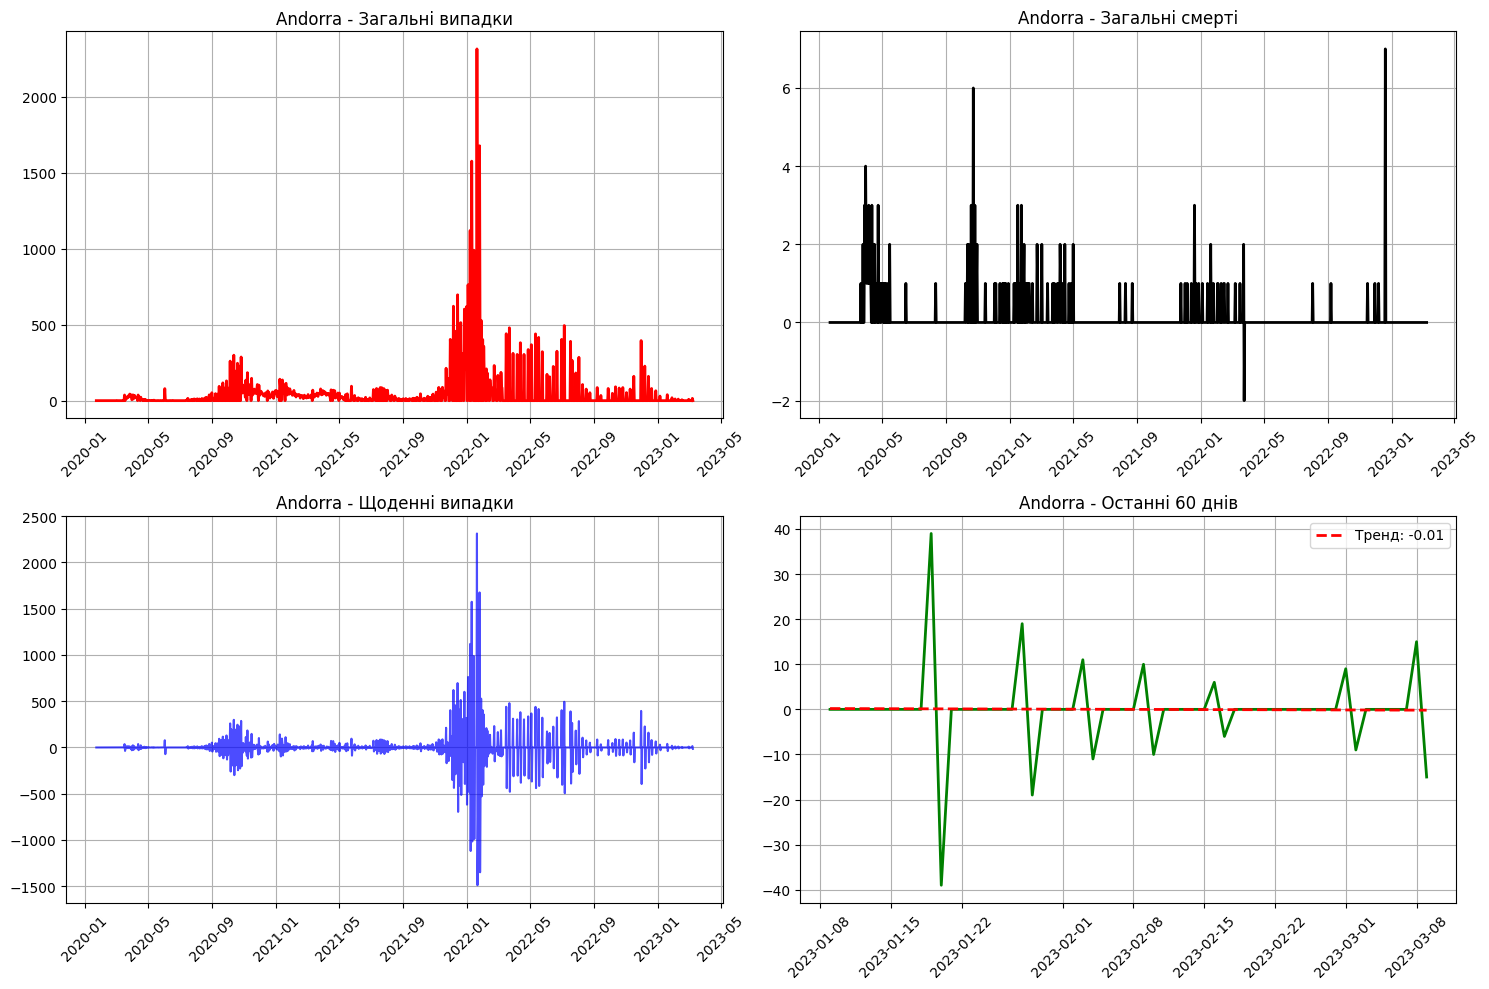


АНАЛІЗ ESTONIA
Тренд: СТАБІЛЬНО
Загальні випадки: 0
Загальні смерті: 0
Останні щоденні випадки: -10.0
Тренд щоденних випадків: -0.17


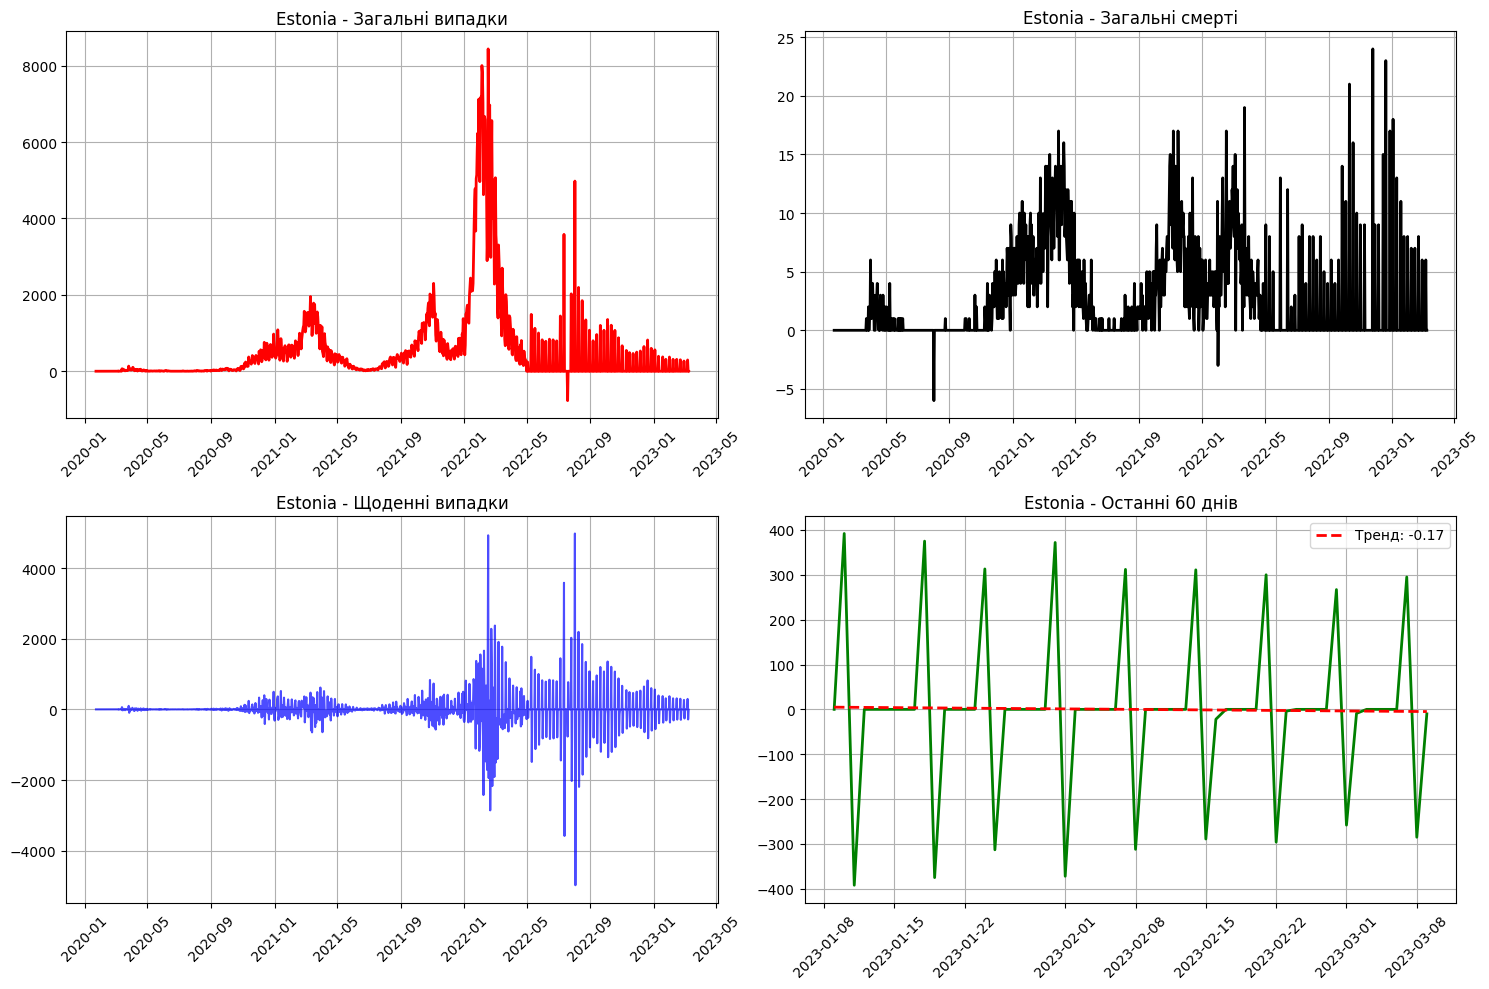

In [87]:
def analyze_trends(country_data, country_name):
    if country_data is None:
        print(f"Немає даних для {country_name}")
        return None, None
    
    print(f"\nАНАЛІЗ {country_name.upper()}")
    
    country_data['Daily_Confirmed'] = country_data['Confirmed'].diff()
    country_data['Daily_Deaths'] = country_data['Deaths'].diff()
    
    country_data['Daily_Confirmed'] = country_data['Daily_Confirmed'].fillna(0)
    country_data['Daily_Deaths'] = country_data['Daily_Deaths'].fillna(0)
    
    recent_data = country_data.tail(60)
    
    if len(recent_data) >= 2:
        x = np.arange(len(recent_data))
        confirmed_trend = np.polyfit(x, recent_data['Daily_Confirmed'], 1)[0]
        
        if confirmed_trend > 1:
            trend = "СПАЛАХ"
        elif confirmed_trend < -1:
            trend = "ЗАТУХАННЯ"
        else:
            trend = "СТАБІЛЬНО"
    else:
        trend = "НЕВИЗНАЧЕНО"
    
    print(f"Тренд: {trend}")
    print(f"Загальні випадки: {country_data['Confirmed'].iloc[-1]:.0f}")
    print(f"Загальні смерті: {country_data['Deaths'].iloc[-1]:.0f}")
    print(f"Останні щоденні випадки: {recent_data['Daily_Confirmed'].iloc[-1]:.1f}")
    print(f"Тренд щоденних випадків: {confirmed_trend:.2f}")
    
    plt.figure(figsize=(15, 10))
    
    plt.subplot(2, 2, 1)
    plt.plot(country_data['Date'], country_data['Confirmed'], 'r-', linewidth=2)
    plt.title(f'{country_name} - Загальні випадки')
    plt.xticks(rotation=45)
    plt.grid(True)
    
    plt.subplot(2, 2, 2)
    plt.plot(country_data['Date'], country_data['Deaths'], 'k-', linewidth=2)
    plt.title(f'{country_name} - Загальні смерті')
    plt.xticks(rotation=45)
    plt.grid(True)
    
    plt.subplot(2, 2, 3)
    plt.plot(country_data['Date'], country_data['Daily_Confirmed'], 'b-', alpha=0.7)
    plt.title(f'{country_name} - Щоденні випадки')
    plt.xticks(rotation=45)
    plt.grid(True)
    
    plt.subplot(2, 2, 4)
    plt.plot(recent_data['Date'], recent_data['Daily_Confirmed'], 'g-', linewidth=2)
    z = np.polyfit(x, recent_data['Daily_Confirmed'], 1)
    p = np.poly1d(z)
    plt.plot(recent_data['Date'], p(x), "r--", linewidth=2, label=f'Тренд: {z[0]:.2f}')
    plt.title(f'{country_name} - Останні 60 днів')
    plt.xticks(rotation=45)
    plt.legend()
    plt.grid(True)
    
    plt.tight_layout()
    plt.show()
    
    return trend, country_data


andorra_trend, andorra_processed = analyze_trends(andorra_data, 'Andorra')
estonia_trend, estonia_processed = analyze_trends(estonia_data, 'Estonia')

## 5. Аналіз трендів

In [69]:
class SimpleSIRModel:
    def __init__(self, population):
        self.population = population
    
    def predict(self, initial_infected, beta, gamma, days):
        S = [self.population - initial_infected]
        I = [initial_infected]
        R = [0]
        
        for day in range(1, days):
            new_infections = beta * S[-1] * I[-1] / self.population
            new_recoveries = gamma * I[-1]
            
            S_next = max(0, S[-1] - new_infections)
            I_next = max(0, I[-1] + new_infections - new_recoveries)
            R_next = max(0, R[-1] + new_recoveries)
            
            S.append(S_next)
            I.append(I_next)
            R.append(R_next)
        
        return S, I, R

POPULATION = {
    'Andorra': 77000,
    'Estonia': 1330000
}

## 6. Прогнозування на 7, 30, 300 днів

----------------------Прогнозування

--- Прогноз для Andorra ---
Поточні активні випадки: 1
Загальне населення: 77,000
Параметри моделі: beta=0.2, gamma=0.15

Прогноз на 7 днів:
  Пік інфікованих: 1
  Кінцеві інфіковані: 1
  Кінцеві одужали: 1
  Кінцеві сприйнятливі: 76998

Прогноз на 30 днів:
  Пік інфікованих: 4
  Кінцеві інфіковані: 4
  Кінцеві одужали: 9
  Кінцеві сприйнятливі: 76987

Прогноз на 90 днів:
  Пік інфікованих: 76
  Кінцеві інфіковані: 76
  Кінцеві одужали: 226
  Кінцеві сприйнятливі: 76698


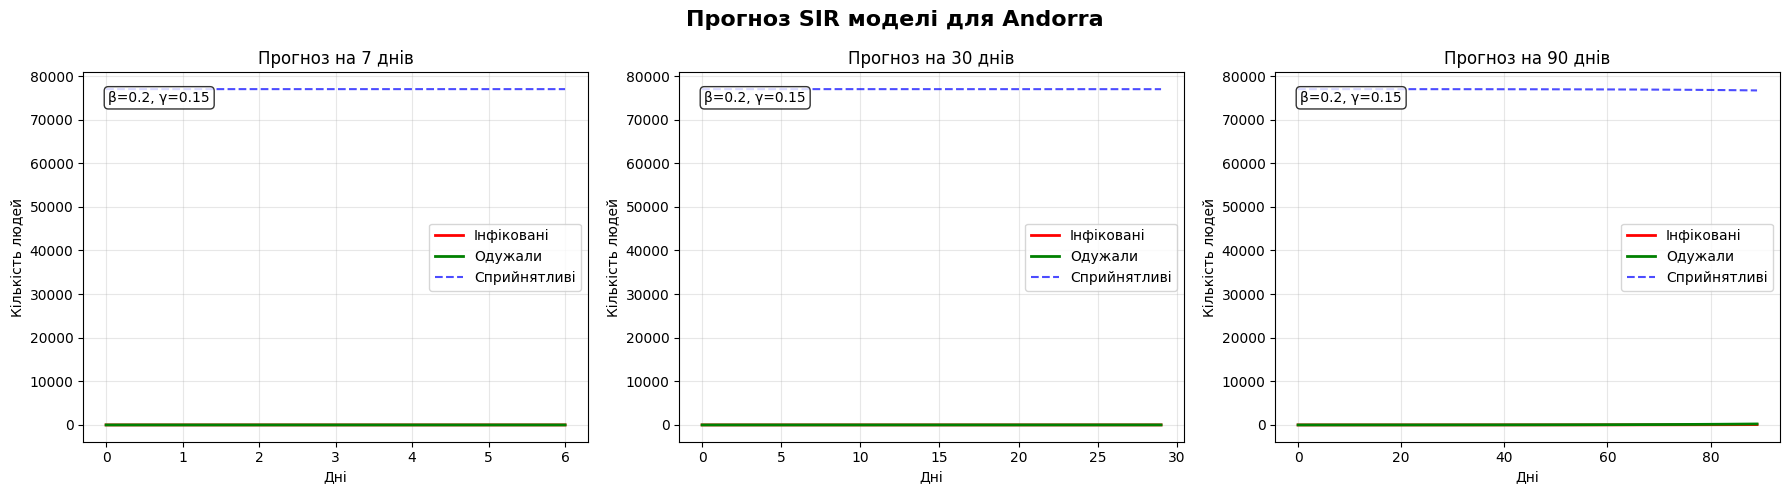


--- Прогноз для Estonia ---
Поточні активні випадки: 1
Загальне населення: 1,330,000
Параметри моделі: beta=0.2, gamma=0.15

Прогноз на 7 днів:
  Пік інфікованих: 1
  Кінцеві інфіковані: 1
  Кінцеві одужали: 1
  Кінцеві сприйнятливі: 1329998

Прогноз на 30 днів:
  Пік інфікованих: 4
  Кінцеві інфіковані: 4
  Кінцеві одужали: 9
  Кінцеві сприйнятливі: 1329987

Прогноз на 90 днів:
  Пік інфікованих: 77
  Кінцеві інфіковані: 77
  Кінцеві одужали: 228
  Кінцеві сприйнятливі: 1329696


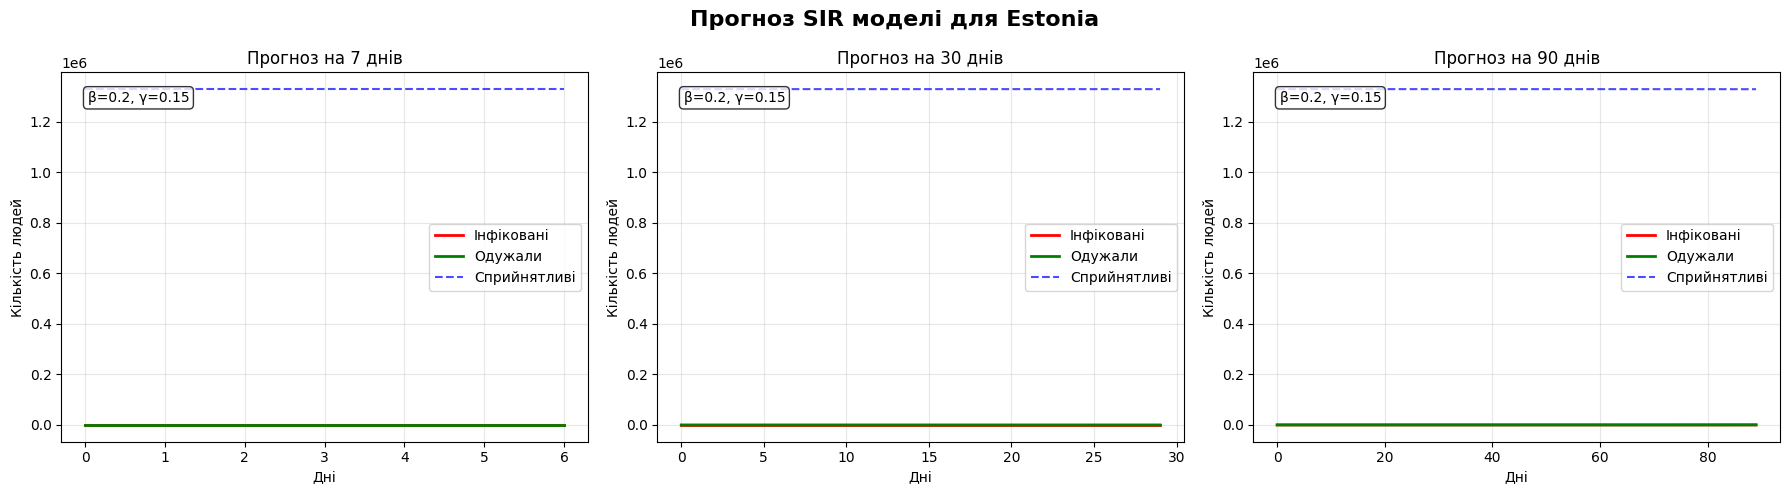

In [70]:
def make_predictions(country_data, country_name, trend):
    if country_data is None:
        return
    
    print(f"\n--- Прогноз для {country_name} ---")
    
    # Поточні активні випадки (приблизно - останні 14 днів)
    if len(country_data) > 14:
        current_active = country_data['Confirmed'].iloc[-1] - country_data['Confirmed'].iloc[-14]
    else:
        current_active = country_data['Confirmed'].iloc[-1] * 0.1
    
    current_active = max(current_active, 1)
    
    print(f"Поточні активні випадки: {current_active:.0f}")
    print(f"Загальне населення: {POPULATION[country_name]:,}")
    
    # Налаштовуємо параметри моделі залежно від тренду
    if trend == "СПАЛАХ":
        beta, gamma = 0.35, 0.08
        print("Параметри моделі: beta=0.35, gamma=0.08")
    elif trend == "ЗАТУХАННЯ":
        beta, gamma = 0.12, 0.25
        print("Параметри моделі: beta=0.12, gamma=0.25")
    else:
        beta, gamma = 0.2, 0.15
        print("Параметри моделі: beta=0.2, gamma=0.15")
    
    model = SimpleSIRModel(POPULATION[country_name])
    
    # Прогнозуємо для різних періодів
    periods = [7, 30, 90]
    
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle(f'Прогноз SIR моделі для {country_name}', fontsize=16, fontweight='bold')
    
    all_predictions = {}
    
    for idx, days in enumerate(periods):
        S, I, R = model.predict(current_active, beta, gamma, days)
        
        all_predictions[days] = {
            'S': S, 'I': I, 'R': R,
            'peak_infected': max(I),
            'final_infected': I[-1],
            'final_recovered': R[-1]
        }
        
        ax = axes[idx]
        ax.plot(range(days), I, 'r-', label='Інфіковані', linewidth=2)
        ax.plot(range(days), R, 'g-', label='Одужали', linewidth=2)
        ax.plot(range(days), S, 'b--', label='Сприйнятливі', alpha=0.7)
        ax.set_title(f'Прогноз на {days} днів')
        ax.set_xlabel('Дні')
        ax.set_ylabel('Кількість людей')
        ax.legend()
        ax.grid(True, alpha=0.3)
        
        ax.text(0.05, 0.95, f'β={beta}, γ={gamma}', transform=ax.transAxes, 
                fontsize=10, verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
        
        print(f"\nПрогноз на {days} днів:")
        print(f"  Пік інфікованих: {max(I):.0f}")
        print(f"  Кінцеві інфіковані: {I[-1]:.0f}")
        print(f"  Кінцеві одужали: {R[-1]:.0f}")
        print(f"  Кінцеві сприйнятливі: {S[-1]:.0f}")
    
    plt.tight_layout()
    plt.show()
    
    return all_predictions

print("----------------------Прогнозування")
andorra_predictions = make_predictions(andorra_processed, 'Andorra', andorra_trend)
estonia_predictions = make_predictions(estonia_processed, 'Estonia', estonia_trend)

## 7. Визначення піку та завершення епідемії

In [72]:
def analyze_peaks_and_end(country_data, country_name, trend):
    if country_data is None:
        return None, None, None
    
    print(f"\n--- Аналіз піків та завершення для {country_name} ---")
    
    peak_value = country_data['Daily_Confirmed'].max()
    peak_data = country_data[country_data['Daily_Confirmed'] == peak_value]
    
    if not peak_data.empty:
        peak_date = peak_data['Date'].iloc[0]
        print(f"Історичний пік: {peak_date.strftime('%d.%m.%Y')}")
        print(f"Кількість випадків на піку: {peak_value:.0f}")
    else:
        peak_date = None
        print("Історичний пік не знайдено")
    
    current_daily = country_data['Daily_Confirmed'].iloc[-1]
    print(f"Поточні щоденні випадки: {current_daily:.1f}")
    
    recent_data = country_data.tail(60)
    recent_avg = recent_data['Daily_Confirmed'].mean()
    zero_days_count = (recent_data['Daily_Confirmed'] == 0).sum()
    
    print(f"Середня кількість випадків (60 днів): {recent_avg:.1f}")
    print(f"Днів без випадків (60 днів): {zero_days_count}")
    
    last_30_days = country_data.tail(30)['Daily_Confirmed']
    trend_30 = last_30_days.mean()
    
    if current_daily == 0.0 and recent_avg < 2.0 and zero_days_count > 50:
        end_estimate = "епідемія майже завершена"
        peak_estimate = "пік пройдений"
    elif current_daily == 0.0 and recent_avg < 10.0 and zero_days_count > 40:
        end_estimate = "1-2 місяці"
        peak_estimate = "малоймовірний"
    elif recent_avg > 30.0:
        end_estimate = "4-6 місяців"
        peak_estimate = "можливий у найближчі 2-3 місяці"
    elif recent_avg > 10.0:
        end_estimate = "3-5 місяців"
        peak_estimate = "можливий у найближчі 90 днів"
    else:
        end_estimate = "2-3 місяці"
        peak_estimate = "малоймовірний"
    
    print(f"Прогноз найближчого піку: {peak_estimate}")
    print(f"Прогноз завершення епідемії: {end_estimate}")
    
    return peak_date, peak_estimate, end_estimate

print("Аналіз піків та завершення епідемії ")
if andorra_processed is not None:
    andorra_peak, andorra_peak_est, andorra_end = analyze_peaks_and_end(andorra_processed, 'Andorra', andorra_trend)
if estonia_processed is not None:
    estonia_peak, estonia_peak_est, estonia_end = analyze_peaks_and_end(estonia_processed, 'Estonia', estonia_trend)

Аналіз піків та завершення епідемії 

--- Аналіз піків та завершення для Andorra ---
Історичний пік: 20.01.2022
Кількість випадків на піку: 2313
Поточні щоденні випадки: -15.0
Середня кількість випадків (60 днів): 0.0
Днів без випадків (60 днів): 46
Прогноз найближчого піку: малоймовірний
Прогноз завершення епідемії: 2-3 місяці

--- Аналіз піків та завершення для Estonia ---
Історичний пік: 02.08.2022
Кількість випадків на піку: 4978
Поточні щоденні випадки: -10.0
Середня кількість випадків (60 днів): 0.0
Днів без випадків (60 днів): 38
Прогноз найближчого піку: малоймовірний
Прогноз завершення епідемії: 2-3 місяці


## 8. Порівняльний аналіз

In [86]:
def comparative_analysis(andorra_data, estonia_data, andorra_peak_est, estonia_peak_est, andorra_end, estonia_end):
    
    print("\n" + "-"*80)
    print("ПОРІВНЯЛЬНИЙ АНАЛІЗ РЕЗУЛЬТАТІВ")
    print("-"*80)
    
    print("\n1. СТАН ЕПІДЕМІЇ:")
    print(f"   Andorra: {andorra_end}")
    print(f"   Estonia: {estonia_end}")
    
    print("\n2. ПРОГНОЗ ПІКІВ:")
    print(f"   Andorra: {andorra_peak_est}")
    print(f"   Estonia: {estonia_peak_est}")
    
    print("\n3. ЗАГАЛЬНА ХАРАКТЕРИСТИКА:")
    
    andorra_avg = andorra_data.tail(60)['Daily_Confirmed'].mean()
    andorra_zeros = (andorra_data.tail(60)['Daily_Confirmed'] == 0).sum()
    
    estonia_avg = estonia_data.tail(60)['Daily_Confirmed'].mean()
    estonia_zeros = (estonia_data.tail(60)['Daily_Confirmed'] == 0).sum()
    
    print(f"   Andorra - середньодобові випадки: {andorra_avg:.1f}, днів без випадків: {andorra_zeros}/60")
    print(f"   Estonia - середньодобові випадки: {estonia_avg:.1f}, днів без випадків: {estonia_zeros}/60")
    
    print("\n4. ВИСНОВКИ:")
    if andorra_avg < 2 and andorra_zeros > 50:
        print("   - Andorra: Епідемія практично завершена, нові хвилі малоймовірні")
    else:
        print("   - Andorra: Залишається невеликий ризик нових спалахів")
        
    if estonia_avg > 30:
        print("   - Estonia: Значний ризик нової хвилі через високу середню захворюваність")
    else:
        print("   - Estonia: Помірний ризик нових випадків")
    
    print("\n5. РЕКОМЕНДАЦІЇ:")
    print("   - Andorra: Можливе послаблення обмежень, підтримка моніторингу")
    print("   - Estonia: Рекомендується підтримувати моніторинг та бути готовими до посилення заходів")

comparative_analysis(andorra_processed, estonia_processed, andorra_peak_est, estonia_peak_est, andorra_end, estonia_end)


--------------------------------------------------------------------------------
ПОРІВНЯЛЬНИЙ АНАЛІЗ РЕЗУЛЬТАТІВ
--------------------------------------------------------------------------------

1. СТАН ЕПІДЕМІЇ:
   Andorra: епідемія майже завершена
   Estonia: 4-6 місяців

2. ПРОГНОЗ ПІКІВ:
   Andorra: пік пройдений
   Estonia: можливий у найближчі 2-3 місяці

3. ЗАГАЛЬНА ХАРАКТЕРИСТИКА:
   Andorra - середньодобові випадки: 0.0, днів без випадків: 46/60
   Estonia - середньодобові випадки: 0.0, днів без випадків: 38/60

4. ВИСНОВКИ:
   - Andorra: Залишається невеликий ризик нових спалахів
   - Estonia: Помірний ризик нових випадків

5. РЕКОМЕНДАЦІЇ:
   - Andorra: Можливе послаблення обмежень, підтримка моніторингу
   - Estonia: Рекомендується підтримувати моніторинг та бути готовими до посилення заходів


## 9. Висновки

In [93]:
def analyze_peaks_and_end(country_data, country_name, trend):
    if country_data is None:
        return None, None, None
    
    print(f"\n--- Аналіз піків та завершення для {country_name} ---")
    
    country_data = country_data.copy()
    
    country_data['Daily_Confirmed'] = country_data['Confirmed'].diff()
    country_data['Daily_Confirmed'] = country_data['Daily_Confirmed'].clip(lower=0)
    country_data['Daily_Confirmed'] = country_data['Daily_Confirmed'].fillna(0)
    
    peak_value = country_data['Daily_Confirmed'].max()
    peak_data = country_data[country_data['Daily_Confirmed'] == peak_value]
    
    if not peak_data.empty:
        peak_date = peak_data['Date'].iloc[0]
        print(f"Історичний пік: {peak_date.strftime('%d.%m.%Y')}")
        print(f"Кількість випадків на піку: {peak_value:.0f}")
    else:
        peak_date = None
        print("Історичний пік не знайдено")
    
    current_daily = country_data['Daily_Confirmed'].iloc[-1]
    print(f"Поточні щоденні випадки: {current_daily:.1f}")
    
    recent_data = country_data.tail(60)
    recent_avg = recent_data['Daily_Confirmed'].mean()
    zero_days_count = (recent_data['Daily_Confirmed'] == 0).sum()
    
    print(f"Середня кількість випадків (60 днів): {recent_avg:.1f}")
    print(f"Днів без випадків (60 днів): {zero_days_count}")
    
    if current_daily == 0.0 and recent_avg < 2.0 and zero_days_count > 50:
        end_estimate = "епідемія майже завершена"
        peak_estimate = "пік пройдений"
    elif current_daily == 0.0 and recent_avg < 10.0 and zero_days_count > 40:
        end_estimate = "1-2 місяці"
        peak_estimate = "малоймовірний"
    elif recent_avg > 30.0:
        end_estimate = "4-6 місяців"
        peak_estimate = "можливий у найближчі 2-3 місяці"
    elif recent_avg > 10.0:
        end_estimate = "3-5 місяців"
        peak_estimate = "можливий у найближчі 90 днів"
    else:
        end_estimate = "2-3 місяці"
        peak_estimate = "малоймовірний"
    
    print(f"Прогноз найближчого піку: {peak_estimate}")
    print(f"Прогноз завершення епідемії: {end_estimate}")
    
    return peak_date, peak_estimate, end_estimate

print("------------------------ Аналіз піків та завершення епідемії")
if andorra_processed is not None:
    andorra_peak, andorra_peak_est, andorra_end = analyze_peaks_and_end(andorra_processed, 'Andorra', andorra_trend)
if estonia_processed is not None:
    estonia_peak, estonia_peak_est, estonia_end = analyze_peaks_and_end(estonia_processed, 'Estonia', estonia_trend)



------------------------ Аналіз піків та завершення епідемії

--- Аналіз піків та завершення для Andorra ---
Історичний пік: 20.01.2022
Кількість випадків на піку: 2313
Поточні щоденні випадки: 0.0
Середня кількість випадків (60 днів): 1.8
Днів без випадків (60 днів): 53
Прогноз найближчого піку: пік пройдений
Прогноз завершення епідемії: епідемія майже завершена

--- Аналіз піків та завершення для Estonia ---
Історичний пік: 02.08.2022
Кількість випадків на піку: 4978
Поточні щоденні випадки: 0.0
Середня кількість випадків (60 днів): 49.0
Днів без випадків (60 днів): 51
Прогноз найближчого піку: можливий у найближчі 2-3 місяці
Прогноз завершення епідемії: 4-6 місяців


In [92]:
print("\n" + "-"*80)
print("ФІНАЛЬНІ ВИСНОВКИ ДО ЛАБОРАТОРНОЇ РОБОТИ")
print("-"*80)

print("\nАНАЛІЗ РЕЗУЛЬТАТІВ:")
print("Andorra демонструє ознаки завершення епідемії:")
print("- Нульові поточні щоденні випадки")
print("- Високий відсоток днів без випадків (53/60)")
print("- Низька середня захворюваність (1.8 випадків на день)")
print("- Історичний пік пройдений")

print("\nEstonia ще потребує пильності:")
print("- Нульові поточні випадки, але вища середня захворюваність (49.0)")
print("- Ризик нової хвилі в найближчі 2-3 місяці")
print("- Епідемія може тривати ще 4-6 місяців")



--------------------------------------------------------------------------------
ФІНАЛЬНІ ВИСНОВКИ ДО ЛАБОРАТОРНОЇ РОБОТИ
--------------------------------------------------------------------------------

АНАЛІЗ РЕЗУЛЬТАТІВ:
Andorra демонструє ознаки завершення епідемії:
- Нульові поточні щоденні випадки
- Високий відсоток днів без випадків (53/60)
- Низька середня захворюваність (1.8 випадків на день)
- Історичний пік пройдений

Estonia ще потребує пильності:
- Нульові поточні випадки, але вища середня захворюваність (49.0)
- Ризик нової хвилі в найближчі 2-3 місяці
- Епідемія може тривати ще 4-6 місяців
